# Notebook: Reproducción de `prueba.py`

Este cuaderno reproduce la lógica de `prueba.py` usando DataFrames en todo momento (no Series).

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opcional: intentar importar sklearn (si está disponible)
try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
except Exception:
    PCA = None
    TSNE = None

In [2]:
# Parámetros y lectura del CSV como DataFrame (usar siempre DataFrames)
csv_path = '../../datos/Activa_columna.csv'
start_ts = '2010-03-01 00:00'
freq = '2min'

# Leer CSV y comprobar
df_vals = pd.read_csv(csv_path)
if df_vals.shape[1] == 0:
    raise SystemExit('CSV vacío o malformado')

# Tomar la primera columna como DataFrame y asegurar nombre
df_col = df_vals.iloc[:, [0]].astype(float)
df_col.columns = ['Demanda']

# Crear índice temporal de 2 minutos y asignarlo
idx = pd.date_range(start=start_ts, periods=len(df_col), freq=freq)
df_col.index = idx

# Remuestrear a horas (media) — sigue siendo DataFrame
hourly = df_col.resample('1h').mean()

# Mostrar una muestra
print('Hourly (primeras filas):')
print(hourly.head())

Hourly (primeras filas):
                       Demanda
2010-03-01 00:00:00  50.778167
2010-03-01 01:00:00  54.506233
2010-03-01 02:00:00  54.582600
2010-03-01 03:00:00  54.063067
2010-03-01 04:00:00  50.085100


In [3]:
# Construir DataFrame día x hora
hourly_df = hourly.reset_index()
hourly_df.columns = ['Fecha', 'Demanda']
hourly_df['date'] = hourly_df['Fecha'].dt.date
hourly_df['hour'] = hourly_df['Fecha'].dt.hour

pivot = hourly_df.pivot(index='date', columns='hour', values='Demanda')
pivot = pivot.reindex(columns=range(24))

# Mantener solo días completos (24 horas)
pivot = pivot.dropna(how='any')

X = pivot.values.astype(float)

print('\nMatriz X (n_días, 24):', X.shape)

print('\n'*3)
print('datos del DataFrame diario (primeras 5 filas):')
pivot.head().round(2)


Matriz X (n_días, 24): (311, 24)




datos del DataFrame diario (primeras 5 filas):


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2010-03-01,50.78,54.51,54.58,54.06,50.09,56.83,54.85,64.85,75.49,109.95,...,107.10,85.62,99.62,104.54,94.60,89.55,74.90,57.63,52.90,48.64
2010-03-02,52.71,51.25,49.51,52.00,51.88,55.99,54.46,66.95,81.73,99.63,...,111.22,83.54,97.75,100.42,96.53,101.75,95.66,70.21,73.23,62.84
2010-03-03,66.81,67.09,61.01,66.03,59.26,64.63,71.93,86.27,94.12,123.39,...,113.64,107.86,96.68,126.04,128.91,105.89,96.20,70.61,69.16,65.22
2010-03-06,58.35,59.36,52.85,55.75,58.46,56.21,56.98,54.72,53.91,51.66,...,50.75,51.58,52.98,58.49,53.25,48.32,51.40,56.12,53.40,56.58
2010-03-07,54.19,52.58,56.70,55.08,53.21,56.02,52.41,49.53,50.44,54.95,...,55.38,57.48,55.00,51.64,52.96,53.86,52.34,56.64,58.91,59.98


In [4]:
# PCA con fallback a SVD
try:
    if PCA is not None:
        pca = PCA(n_components=2)
        pr = pca.fit_transform(X)
    else:
        raise ImportError
except Exception:
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    pr = U[:, :2] * S[:2]

print('Proyección PCA (shape):', pr.shape)

Proyección PCA (shape): (311, 2)


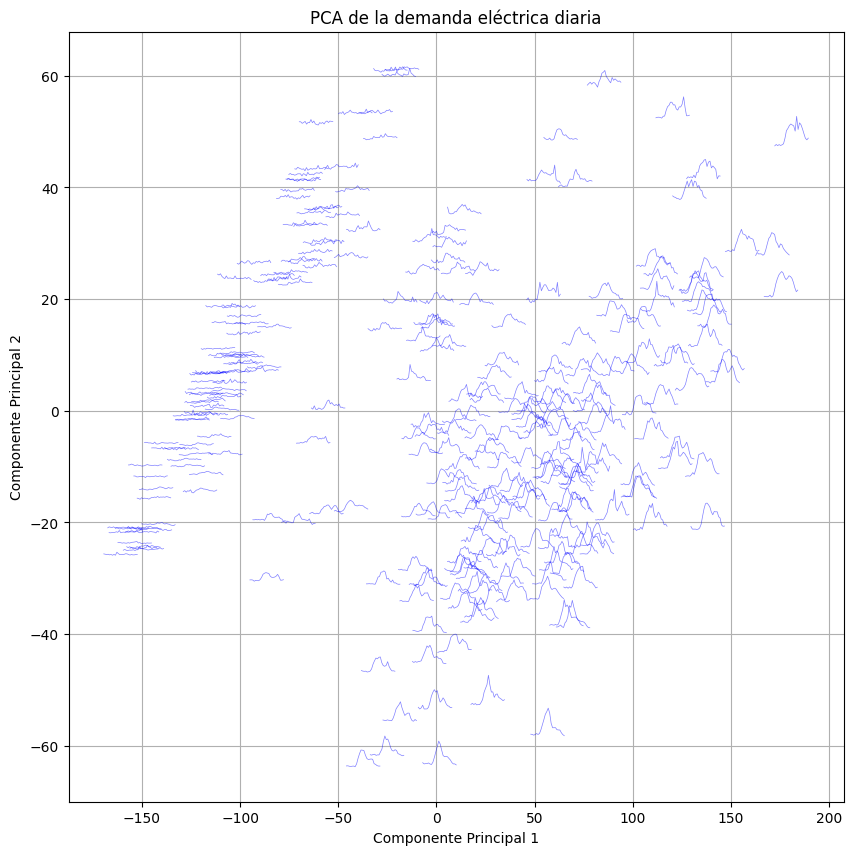

In [5]:
# Visualización PCA con escalas automáticas para los sparklines
plt.figure(figsize=(10,10))

# Normalizar formas diarias (sparklines)
Xnorm = X / np.abs(X.ravel()).max()
Xnorm = Xnorm - Xnorm.mean(axis=1, keepdims=True)
t = np.linspace(-0.1, 0.1, 24)

# Cálculo automático de escalas basadas en el rango de la proyección
range_px = np.ptp(pr[:, 0])
range_py = np.ptp(pr[:, 1])
range_t = t.max() - t.min() if (t.max() - t.min()) != 0 else 1.0
range_xnorm = np.ptp(Xnorm) if np.ptp(Xnorm) != 0 else 1.0

# Factores manuales (ajustables) — reducidos por 4 respecto a valores anteriores
PCA_HOR_FACTOR = 0.05    # antes ~0.2, reducido x4
PCA_VER_FACTOR = 0.05    # antes ~0.6, reducido x4

# Escalas finales usadas para dibujar los sparklines
scale_x = PCA_HOR_FACTOR * range_px / range_t if range_px > 0 else 0.5 * PCA_HOR_FACTOR
scale_y = PCA_VER_FACTOR * range_py / range_xnorm if range_py > 0 else 1.0 * PCA_VER_FACTOR

for i in range(pr.shape[0]):
    plt.plot(pr[i, 0] + t * scale_x, pr[i, 1] + Xnorm[i, :] * scale_y,
             color='blue', alpha=0.5, linewidth=0.5)

plt.title('PCA de la demanda eléctrica diaria')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid()
plt.show()

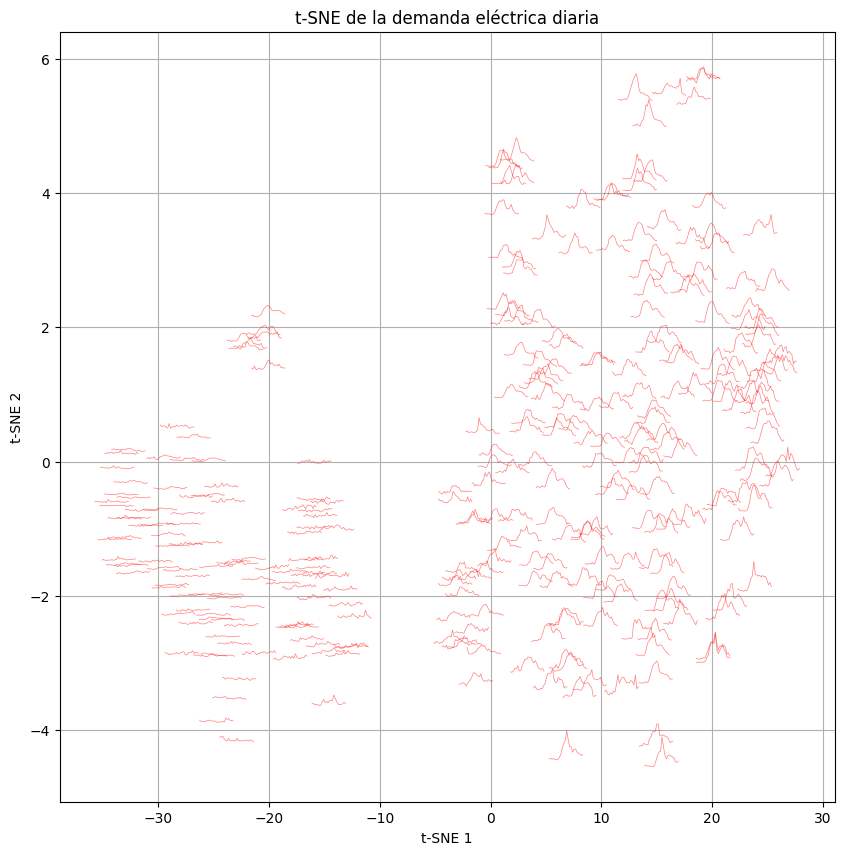

In [6]:
# t-SNE con fallback a la proyección PCA y escalas automáticas
try:
    if TSNE is not None:
        tsne_proj = TSNE(n_components=2, random_state=0).fit_transform(X)
    else:
        raise ImportError
except Exception:
    tsne_proj = pr.copy()

plt.figure(figsize=(10,10))

# Recalcular Xnorm y t por independencia de la celda
Xnorm = X / np.abs(X.ravel()).max()
Xnorm = Xnorm - Xnorm.mean(axis=1, keepdims=True)
t = np.linspace(-0.1, 0.1, 24)

# Rangos para tsne
range_tx = np.ptp(tsne_proj[:, 0])
range_ty = np.ptp(tsne_proj[:, 1])
range_t = t.max() - t.min() if (t.max() - t.min()) != 0 else 1.0
range_xnorm = np.ptp(Xnorm) if np.ptp(Xnorm) != 0 else 1.0

# Factores manuales (ajustables) — reducidos x4 respecto a valores anteriores
TSNE_HOR_FACTOR = 0.05   # antes ~0.15, reducido x4
TSNE_VER_FACTOR = 0.05     # antes ~0.4, reducido x4

# Escalas automáticas (con factores explícitos)
scale_x_tsne = TSNE_HOR_FACTOR * range_tx / range_t if range_tx > 0 else 0.3 * TSNE_HOR_FACTOR
scale_y_tsne = TSNE_VER_FACTOR * range_ty / range_xnorm if range_ty > 0 else 0.7 * TSNE_VER_FACTOR

for i in range(tsne_proj.shape[0]):
    plt.plot(tsne_proj[i, 0] + t * scale_x_tsne,
             tsne_proj[i, 1] + Xnorm[i, :] * scale_y_tsne,
             color='red', alpha=0.5, linewidth=0.5)

plt.title('t-SNE de la demanda eléctrica diaria')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid()
plt.show()

/Users/idiazblanco/Documents/Docencia/Mecatronica/Seminario Machine Learning 2024/ejemplos-curso-ML/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


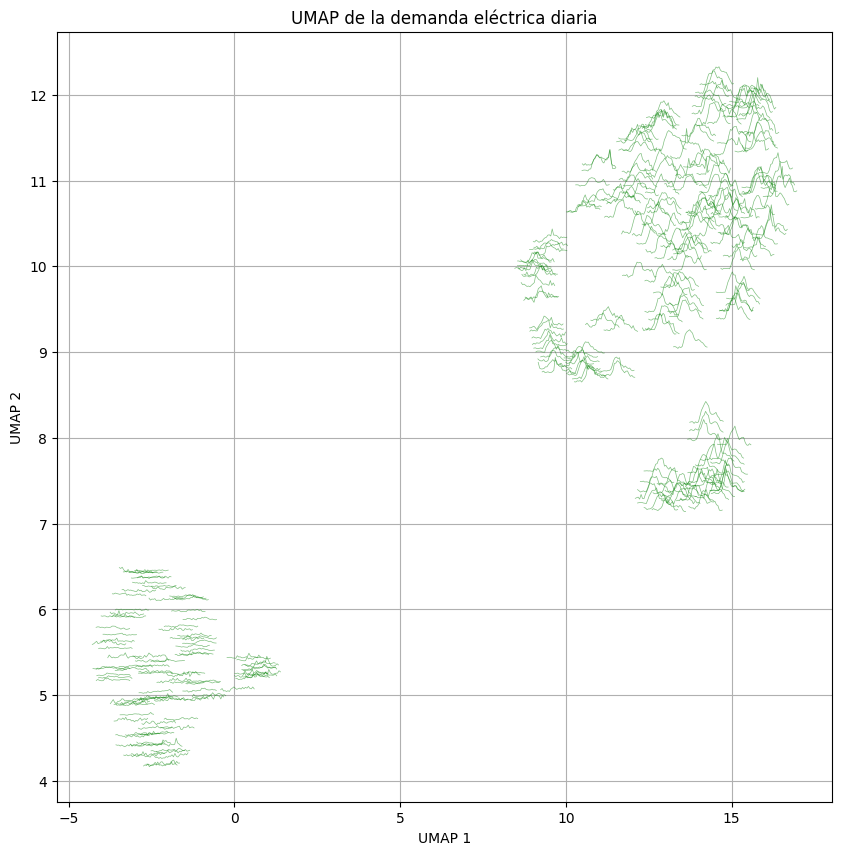

In [23]:
# UMAP con fallback a PCA y mismo estilo visual que PCA/t-SNE
try:
    import umap.umap_ as umap
    umap_proj = umap.UMAP(n_components=2, min_dist=0.1, n_neighbors=5, metric='cosine', random_state=0).fit_transform(X)
except Exception:
    umap_proj = pr.copy()

plt.figure(figsize=(10,10))

# Normalizar formas diarias (sparklines)
Xnorm = X / np.abs(X.ravel()).max()
Xnorm = Xnorm - Xnorm.mean(axis=1, keepdims=True)
t = np.linspace(-0.1, 0.1, 24)

# Rangos para UMAP
range_ux = np.ptp(umap_proj[:, 0])
range_uy = np.ptp(umap_proj[:, 1])
range_t = t.max() - t.min() if (t.max() - t.min()) != 0 else 1.0
range_xnorm = np.ptp(Xnorm) if np.ptp(Xnorm) != 0 else 1.0

# Factores manuales (ajustables) — reducir si hay solapamiento
UMAP_HOR_FACTOR = 0.05
UMAP_VER_FACTOR = 0.05

scale_x_umap = UMAP_HOR_FACTOR * range_ux / range_t if range_ux > 0 else 0.3 * UMAP_HOR_FACTOR
scale_y_umap = UMAP_VER_FACTOR * range_uy / range_xnorm if range_uy > 0 else 0.7 * UMAP_VER_FACTOR

for i in range(umap_proj.shape[0]):
    plt.plot(umap_proj[i, 0] + t * scale_x_umap,
             umap_proj[i, 1] + Xnorm[i, :] * scale_y_umap,
             color='green', alpha=0.5, linewidth=0.5)

plt.title('UMAP de la demanda eléctrica diaria')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid()
plt.show()